## Worked Solutions for Notebook 4

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import skimage
import skimage.io
import skimage.morphology
import skimage.segmentation
import skimage.color
import scipy.ndimage as ndi
import stackview
import ipywidgets as widgets

## Excercise 1
Segmentation of blobs and filtering by a morphological feature: We're going to filter out elongated blobs

Steps: 
1. Load blobs and visualize
2. Segment blobs
3. Make measurements to filter the blobs by shape (aspect ratio and eccentricity)
4. Plot a histogram of the aspect ratio or eccentricity
5. Filter the measurements
6. Plot the label image without the elongated shapes. (option: keep original labels)

### 1. Load blobs image from the images folder and vizualise it
   
   Blobs are in "images/blobs.tif"


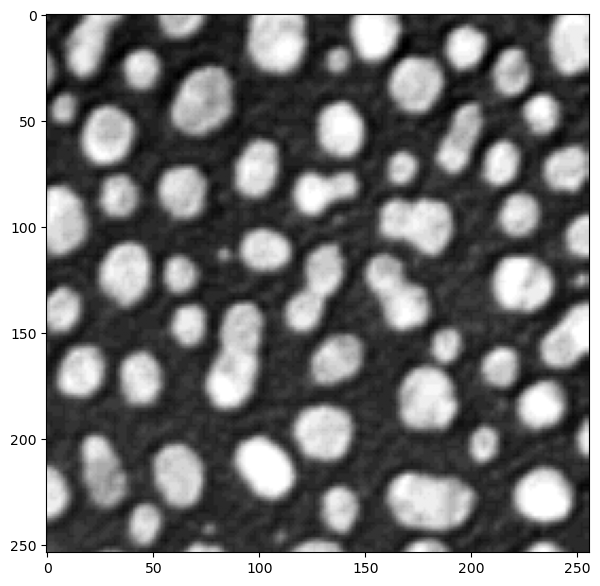

In [27]:
# Solution

image_ex_1 = skimage.io.imread('images/blobs.tif')
plt.subplots(figsize=(7,7))
plt.imshow(image_ex_1, cmap = 'gray');

### 2. Segment the blobs
 Threshold the blobs to create a segmentation map.  Create segmentation labels

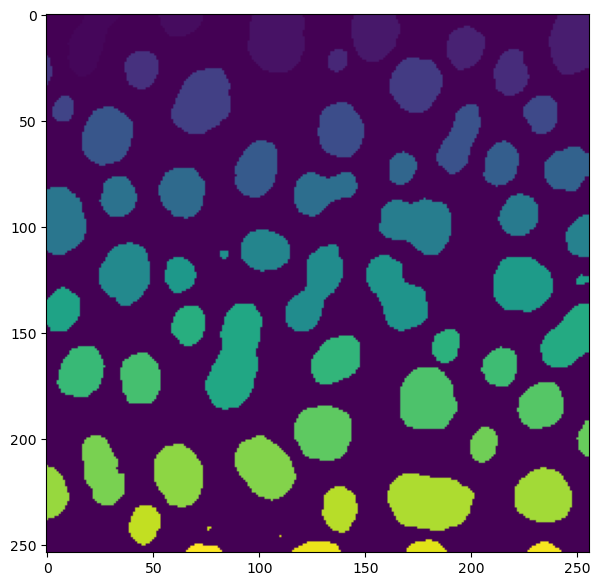

In [28]:

mask_blobs = image_ex_1 > skimage.filters.threshold_otsu(image_ex_1)
label_blobs = skimage.morphology.label(mask_blobs)
                       
plt.subplots(figsize=(7,7))
plt.imshow(label_blobs);

### 3. Find a way to filter the blobs that have elongated shapes.  
Try creating a new dataframe column with a new measure ("aspect_ratio") that would give you a measure of the length to width (maybe the minor axis vs major axis length).  What other measurements might work? Find another measurement that could also work. Filter your blobs by the aspect ratio or other measure

#### Aspect Ratio measure

In [29]:
results = skimage.measure.regionprops_table(label_blobs, properties=('label', 'axis_major_length', 'axis_minor_length'))
results_df = pd.DataFrame(results)
results_df.head()

,label,axis_major_length,axis_minor_length
0,1,34.957399,16.819060
1,2,21.061417,11.803854
2,3,30.212552,28.278264
3,4,24.535398,23.064079
4,5,31.162612,19.833058


In [37]:
results_df['aspect_ratio'] = results_df['axis_major_length'] / results_df['axis_minor_length']
results_df.head()

,label,axis_major_length,axis_minor_length,aspect ratio,aspect_ratio
0,1,34.957399,16.819060,2.078439,2.078439
1,2,21.061417,11.803854,1.784283,1.784283
2,3,30.212552,28.278264,1.068402,1.068402
3,4,24.535398,23.064079,1.063793,1.063793
4,5,31.162612,19.833058,1.571246,1.571246


#### Eccentricity measure

In [39]:
results_with_ecc = skimage.measure.regionprops_table(label_blobs, properties=('label', 'axis_major_length', 'axis_minor_length', 'eccentricity'))
results_with_ecc_df = pd.DataFrame(results_with_ecc)
results_with_ecc_df['aspect_ratio'] = results_df['axis_major_length'] / results_df['axis_minor_length']
results_with_ecc_df.head()


,label,axis_major_length,axis_minor_length,eccentricity,aspect_ratio
0,1,34.957399,16.819060,0.876649,2.078439
1,2,21.061417,11.803854,0.828189,1.784283
2,3,30.212552,28.278264,0.352060,1.068402
3,4,24.535398,23.064079,0.341084,1.063793
4,5,31.162612,19.833058,0.771328,1.571246


### 4. Plot a histogram of the aspect ratio or eccentricity

array([[<Axes: title={'center': 'eccentricity'}>]], dtype=object)

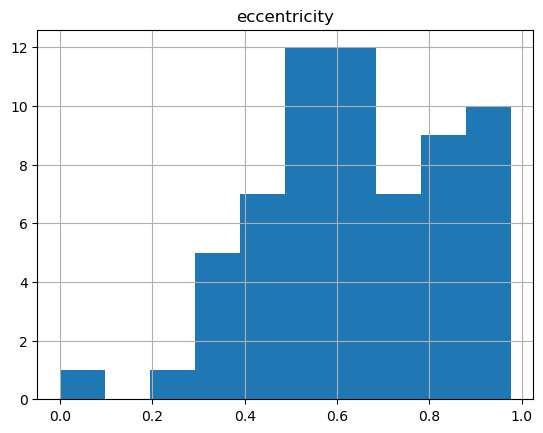

In [40]:
results_with_ecc_df.hist('eccentricity')

array([[<Axes: title={'center': 'aspect_ratio'}>]], dtype=object)

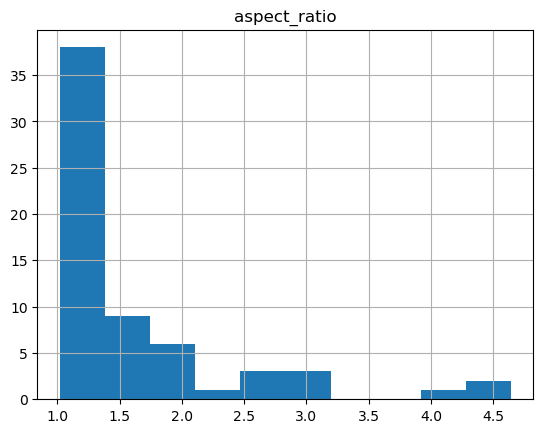

In [44]:
results_df.hist('aspect_ratio')



### 5. Filter the blobs to remove those that are elongated
Here I'm doing both by aspect ratio and eccentricity.  

In [45]:
#Aspect ratio
results_elongated_removed = results_df[results_df['aspect_ratio'] < 1.5]
print("There are : ", str(len(results_elongated_removed)), " objects after filtering and : ", str(len(results_df)), " before filtering") 
results_elongated_removed.head()

There are :  42  objects after filtering and :  64  before filtering


,label,axis_major_length,axis_minor_length,aspect ratio,aspect_ratio
2,3,30.212552,28.278264,1.068402,1.068402
3,4,24.535398,23.064079,1.063793,1.063793
5,6,20.506730,17.770536,1.153974,1.153974
6,7,11.153514,9.239435,1.207164,1.207164
7,8,22.298284,16.037201,1.390410,1.390410


In [46]:
#Eccentricity
results_elongated_ecc_removed = results_with_ecc_df[results_with_ecc_df['eccentricity'] < 0.75]
print("There are : ", str(len(results_elongated_ecc_removed)), " objects after filtering and : ", str(len(results_with_ecc_df)), " before filtering") 
results_elongated_ecc_removed.head()

There are :  43  objects after filtering and :  64  before filtering


,label,axis_major_length,axis_minor_length,eccentricity,aspect_ratio
2,3,30.212552,28.278264,0.352060,1.068402
3,4,24.535398,23.064079,0.341084,1.063793
5,6,20.506730,17.770536,0.499054,1.153974
6,7,11.153514,9.239435,0.560155,1.207164
7,8,22.298284,16.037201,0.694790,1.390410


### 6. Plot the label image without the elongated shapes

the np.isin function will compare two groups of elements, and removes from the first group elements that aren't in the second 

https://numpy.org/doc/stable/reference/generated/numpy.isin.html

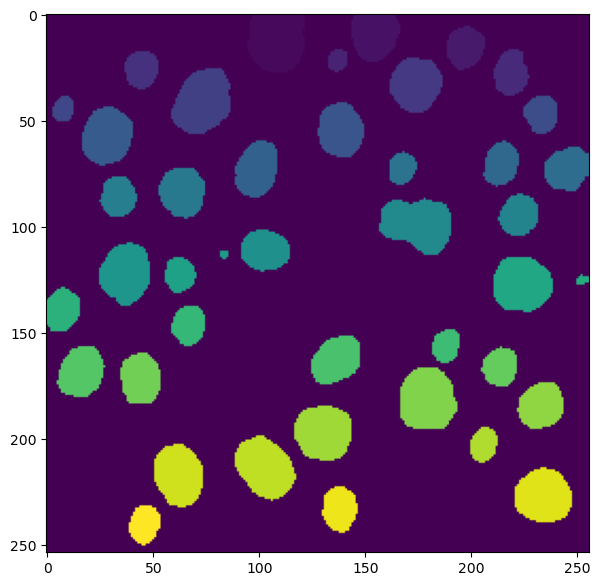

In [47]:
# Create a mask of only the non-elongated blobs
filtered_labels = np.isin(label_blobs, results_elongated_removed['label'])

# Relabel the filtered mask for visualization
filtered_labels_relabel = skimage.segmentation.relabel_sequential(filtered_labels * label_blobs)[0]

plt.subplots(figsize=(7,7))
plt.imshow(filtered_labels_relabel);

### 6 option. Keep the same label values:

Use np.where to keep the original labels

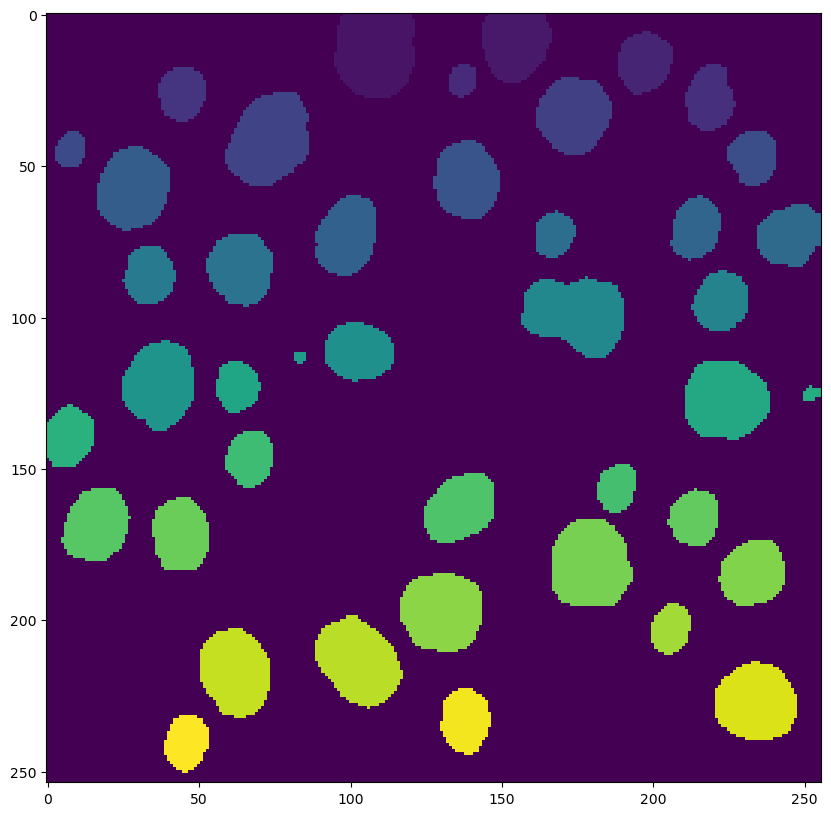

In [48]:
filtered_labels = np.where(np.isin(label_blobs, results_elongated_removed['label']), label_blobs, 0)

plt.subplots(figsize=(10,10))
plt.imshow(filtered_labels);

### 7. From your initial segmentation, split the most elongated objects

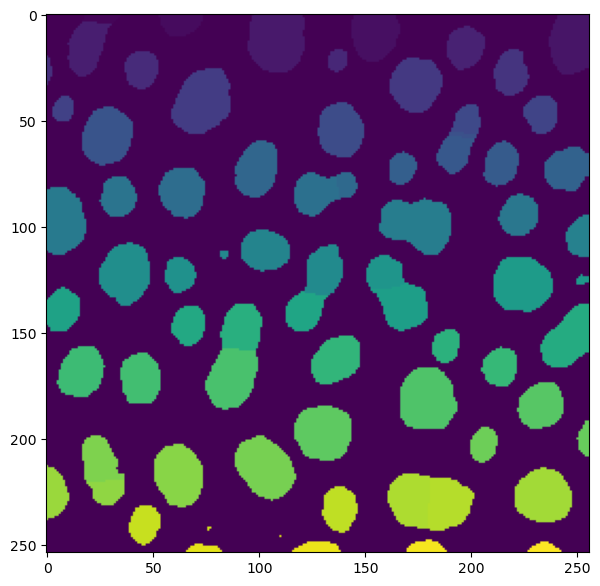

In [49]:
# compute distance transform from masks
distance = ndi.distance_transform_edt(mask_blobs)
# blur helps reduce the noise and minor irregularities in the distance values 
blurred_distance = skimage.filters.gaussian(distance, sigma=2)
fp = np.ones((3,3))

# compute local max of blurred distance map
coords = skimage.feature.peak_local_max(blurred_distance, footprint=fp, labels=mask_blobs)

# create an array with labeled markers 
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers = skimage.measure.label(mask)
# apply the watershed algorithm
labels = skimage.segmentation.watershed(-blurred_distance, markers, mask=mask_blobs)

plt.subplots(figsize=(7,7))
plt.imshow(labels)

# Solution 2 Computing Distances Between Objects

In some projects, you might be interested in computing distances between different objects. For example, to filter out objects that are far away from an other set of objects. An efficient approach is based on distance maps, and we will see an example of usage along with ```skimage.measure.regionprops_table()``` method in the exercise 2 below. We give before a little theory reminder about distance maps.

Distance transforms have many applications, we can for example use them to quantify how a structure of interest is away from object boundaries or other structures as just mentionned. They are also used to characterize the morphology of an object in 2D and 3D, find its center, dimensions, etc.. Distance transforms can also be used as a pre-processing step to improve the segmentation results and split touching objects. Distance maps may use different distance metrics, as the Euclidian or the Manhattan one for example.

<img src="illustrations/distance_maps.png" alt="drawing" width="50%" class="center"/>

Image [source](https://neubias.github.io/training-resources/distance_transform/index.html#:~:text=We%20use%20distance%20transform%20to,center%2C%20dimensions%2C%20etc..)

## Steps:
1. Open hela cells image and visualize the different channels.  Images are at images\hela-cells.tif
2. Segment the nuclei on the last channel
3. Detect lysosomes on the first channel and convert them to a label map
4. Compute a distance map and inverse distance map of nuclei. 
5. Compte distances from lysosomes to closest nuclei.  Hint: you can use regionprops


### Step 1. 
Open hela cells image and visualize the different channels.  Images are at images\hela-cells.tif

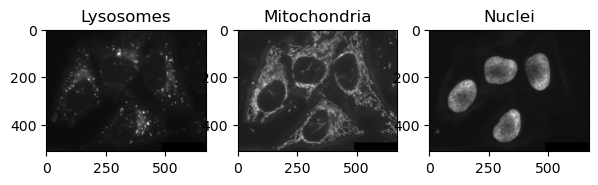

In [12]:
hela_cells = skimage.io.imread('images/hela-cells.tif')
chan_1 = hela_cells[:,:,0] # red channel in RGB
chan_2 = hela_cells[:,:,1] # green channel in RGB
chan_3 = hela_cells[:,:,2] # blue channel in RGB

fig, ax = plt.subplots(1, 3, figsize=(7,7))
ax[0].imshow(chan_1, cmap='gray')
ax[1].imshow(chan_2, cmap='gray')
ax[2].imshow(chan_3, cmap='gray')
ax[0].set_title('Lysosomes');
ax[1].set_title('Mitochondria');
ax[2].set_title('Nuclei');

In [13]:
# Solution cell 2

stackview.switch(
    {"lysosomes":   hela_cells[:,:,0],
     "mitochondria":hela_cells[:,:,1],
     "nuclei":      hela_cells[:,:,2]
    },
    colormap=["pure_magenta", "pure_green", "pure_blue"],
    toggleable=True
)

### Step 2.
Segment the nuclei on the last channel

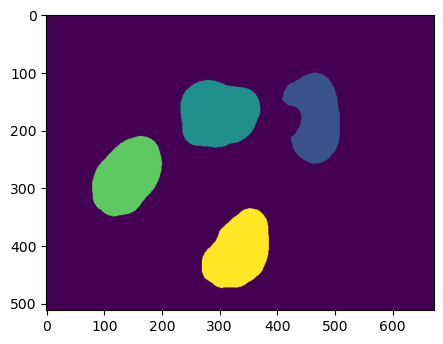

In [14]:
chan_3_blurred = skimage.filters.gaussian(chan_3, sigma=2)
mask_nuclei = chan_3_blurred > skimage.filters.threshold_otsu(chan_3_blurred)
mask_nuclei = skimage.morphology.binary_closing(mask_nuclei, footprint=skimage.morphology.disk(20))
mask_nuclei = skimage.morphology.remove_small_objects(ndi.binary_fill_holes(mask_nuclei, skimage.morphology.disk(5)))
label_nuclei = skimage.morphology.label(mask_nuclei)
                       
plt.subplots(figsize=(5,5))
plt.imshow(label_nuclei);

### Step 3.
Detect lysosomes on the first channel and convert them to a label map

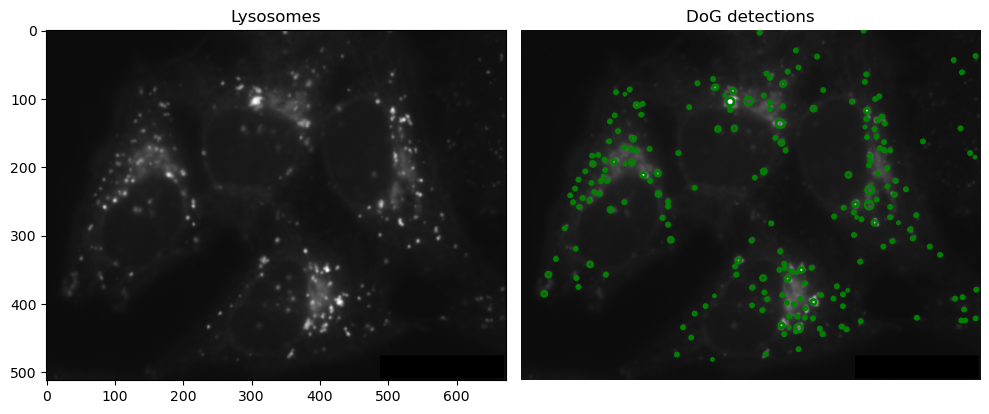

In [15]:
blobs_dog = skimage.feature.blob_dog(chan_1.astype(float), min_sigma=1, max_sigma=6, threshold_rel=0.1)
blobs_dog[:, 2] = blobs_dog[:, 2] * math.sqrt(2) # store radii in third column

fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(chan_1, cmap='gray')
ax[0].set_title('Lysosomes')
ax[1].imshow(chan_1, cmap='gray')
for blob in blobs_dog:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='green', linewidth=2, fill=False)
    ax[1].add_patch(c)
    ax[1].set_axis_off()
ax[1].set_title('DoG detections')
plt.tight_layout()
plt.show()

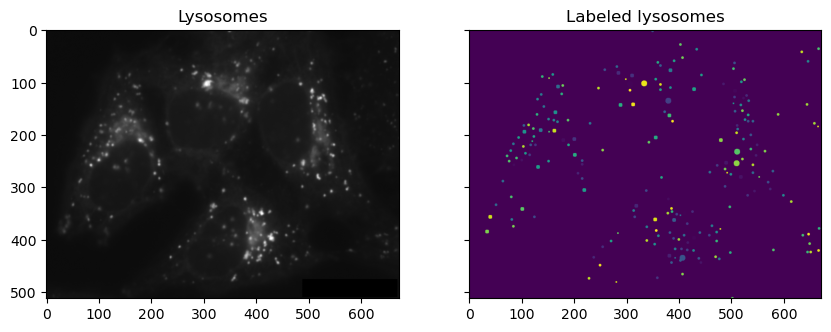

In [16]:
## convert to label map:
label_lysosomes = np.zeros(chan_1.shape, dtype=np.int32)
for i, lysosome in enumerate(blobs_dog, 1): # Start labeling from 1
        y, x, r = lysosome
        rr, cc = skimage.draw.disk((y, x), r)
        if(((y+r) < chan_1.shape[0]) and ((x+r) < chan_1.shape[1])):
            label_lysosomes[rr, cc] = i

fig, ax = plt.subplots(1, 2, figsize=(10,10), sharex=True, sharey=True)
ax[0].imshow(chan_1, cmap='gray');
ax[0].set_title('Lysosomes');
ax[1].imshow(label_lysosomes);
ax[1].set_title('Labeled lysosomes');
plt.show()

### Step 4.
Compute a distance map and inverse distance map of nuclei.  What do the distance maps with gray look like? With nipy_spectral ?

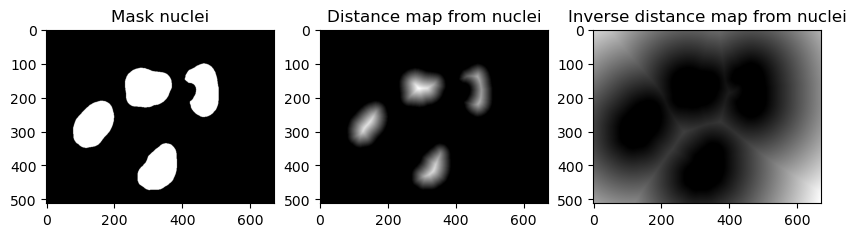

In [17]:
distance_map_nuclei = ndi.distance_transform_edt(mask_nuclei)
inv_distance_map_nuclei = ndi.distance_transform_edt(1 - mask_nuclei)

fig, ax = plt.subplots(1, 3, figsize=(10,10))
ax[0].imshow(mask_nuclei, cmap='gray');
ax[0].set_title('Mask nuclei');
ax[1].imshow(distance_map_nuclei, cmap = 'gray');
ax[1].set_title('Distance map from nuclei');
ax[2].imshow(inv_distance_map_nuclei, cmap = 'gray');
ax[2].set_title('Inverse distance map from nuclei');

In [18]:
stackview.picker(distance_map_nuclei)

In [19]:
stackview.picker(inv_distance_map_nuclei)

### Step 5.
Compute distances from lysosomes to closest nuclei.  Hint: you can use regionprops

Text(0, 0.5, 'Count of lysosomes')

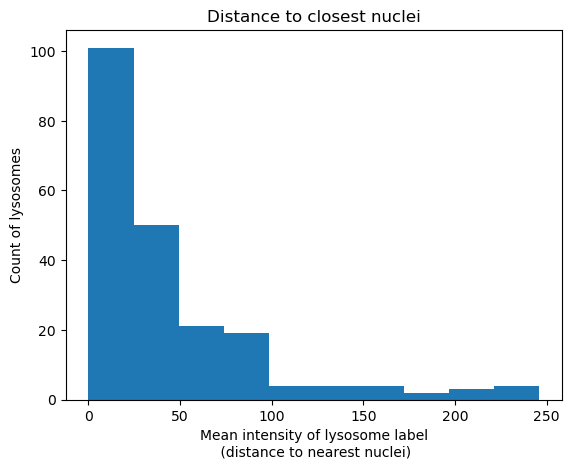

In [20]:
# compute mean intensity value of distance map image from lysosomes label image
results = skimage.measure.regionprops_table(label_lysosomes, inv_distance_map_nuclei, properties=('label','area', 'mean_intensity'))
## intensity is measured from the inv_distance _map_nuclei image. So for each label_lysosome, we measure the average intensity of the inverse distance map, under the lysosome label. 
## The intensity under the label is the distance to the nearest nuclei


results_df = pd.DataFrame(results)
plt.hist(results_df['mean_intensity'])
plt.title("Distance to closest nuclei")
plt.xlabel("Mean intensity of lysosome label\n (distance to nearest nuclei)")     
plt.ylabel("Count of lysosomes")            

stackview.clusterplot(image=chan_3,
                     labels=label_lysosomes,
                     df=results_df,
                     column_x="label",
                     column_y="mean_intensity", 
                     zoom_factor=0.8,
                     alpha=0.7)

## [OPTIONAL] Exercise 3

Steps:
1. Import the image from images/4color_cells.tif and visualize the 3rd channel
2. Create a mask using the third channel and label objects
3. Measure the region properties using this labeled image and use the fourth channel as intensity image
4. Extract the mean_intensity property from the dictionary and plot an histogram of these intensities
5. What do you observe in this histogram ? Plot the fourth channel using stackview.picker and see if the histogram makes sense

#### Step 1.
Import the image from images/4color_cells.tif and visualize the 3rd channel

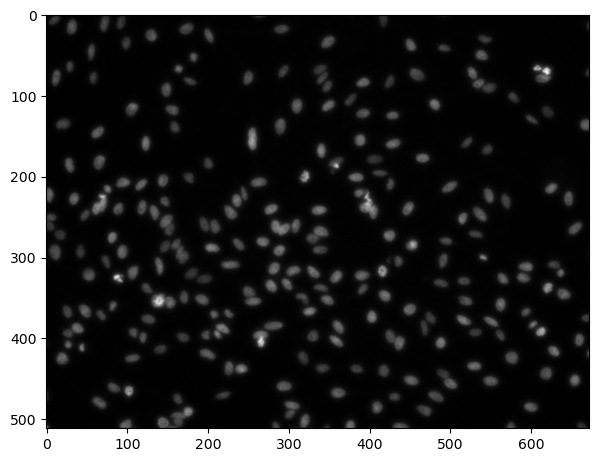

In [21]:
image_ex_3 = skimage.io.imread('images/4color_cells.tif')
chan_3 = image_ex_3[:,:,2]
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(chan_3, cmap = 'gray');

### Step 2.
Create a mask using the third channel and label objects

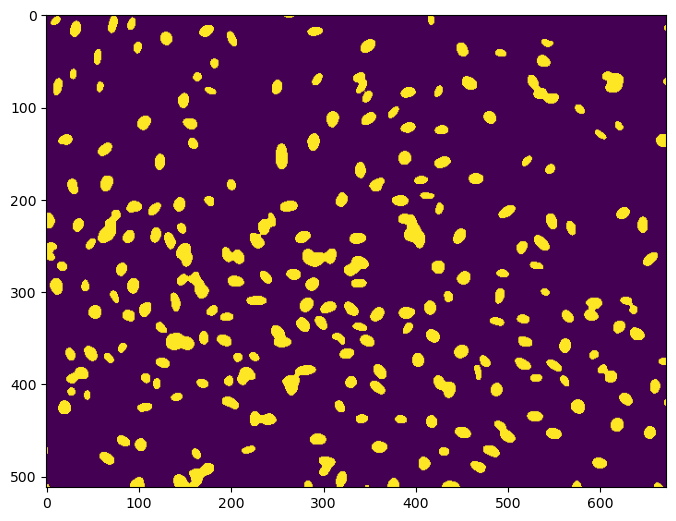

In [22]:
chan_3 = skimage.filters.median(chan_3, skimage.morphology.disk(3))  #blur the image
masks = chan_3 > skimage.filters.threshold_otsu(chan_3)   #create the masks

plt.subplots(figsize=(8,8))
plt.imshow(masks);

In [23]:
distance = ndi.distance_transform_edt(masks)
blurred_distance = skimage.filters.gaussian(distance, sigma=2)
fp = np.ones((3,3))

coords = skimage.feature.peak_local_max(blurred_distance, footprint=fp, labels=masks)
mask = np.zeros(blurred_distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers = skimage.measure.label(mask)
labels_ex_3 = skimage.segmentation.watershed(-blurred_distance, markers, mask=masks)

stackview.picker(labels_ex_3)

### Step 3. 
Measure the region properties using this labeled image and use the fourth channel as intensity image

In [24]:
results = skimage.measure.regionprops_table(labels_ex_3, image_ex_3[:,:,3], properties=('label','mean_intensity'))

### Step 4.
Extract the mean_intensity property from the dictionary and plot an histogram of these intensities

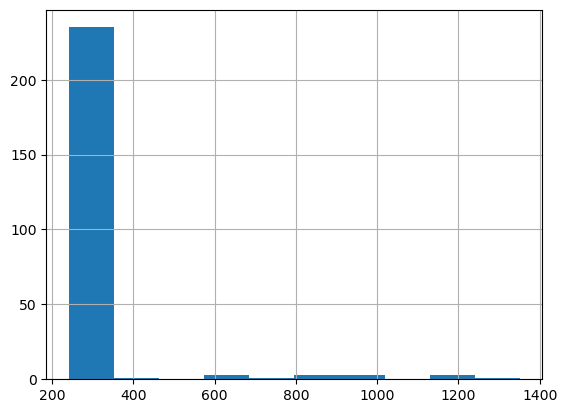

In [25]:
results_df = pd.DataFrame(results)
results_df['mean_intensity'].hist();

### Step 5.
What do you observe in this histogram ? Plot the fourth channel and see if the histogram makes sense

In [26]:
stackview.picker(image_ex_3[:,:,3])